# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [2]:
building_consumption = pd.read_csv("Data/2016_Building_Energy_Benchmarking.csv")

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE

A réaliser :
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse :

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier

In [5]:
# On vérifie et on stocke le nombre de lignes de départ pour rappel
nb_lignes_initial = building_consumption.shape[0]
print(f"Nombre de bâtiments avant filtrage : {nb_lignes_initial}")

# Voir les types dispo dans BuildingTypes
print(building_consumption["BuildingType"].value_counts())

Nombre de bâtiments avant filtrage : 3376
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


In [6]:
# Je conserve uniquement ceux qui ne commencent PAS par Multifamily car il me semble que ce sont eux
# qui sont les batiments résidentiels
building_consumption = building_consumption[~building_consumption["BuildingType"].str.contains("Multifamily")]

# On voit donc l'écart
nb_lignes_apres_filtrage = building_consumption.shape[0]
print(f"Nombre de bâtiments après filtrage résidentiel : {nb_lignes_apres_filtrage}")
print(f"Lignes supprimées : {nb_lignes_initial - nb_lignes_apres_filtrage}")

Nombre de bâtiments après filtrage résidentiel : 1668
Lignes supprimées : 1708


Détection des colonnes sans valeur ajoutées pour suppression

In [7]:
# On construit un tableau récapitulatif : une ligne par colonne du dataset
resume_colonnes = pd.DataFrame({
    "type": building_consumption.dtypes,
    "nb_valeurs_uniques": building_consumption.nunique(),
    "nb_lignes": len(building_consumption),
    "nb_manquants": building_consumption.isnull().sum(),
})

# Colonne pratique : le ratio "tx_valeurs_uniques"
# proche de 1.0 -> beaucoup de valeurs différentes
# proche de 0.0 -> peu de valeurs différentes, très similaires
resume_colonnes["tx_valeurs_uniques"] = (resume_colonnes["nb_valeurs_uniques"] / resume_colonnes["nb_lignes"]).round(3)

# Tri du plus pour repérer d'un coup d'oeil les colonnes qui ont beaucoup de valeurs uniques
# les colonnes candidates à supprimer (ratio proche de 1, ou nb_valeurs_uniques == 1)
resume_colonnes = resume_colonnes.sort_values("tx_valeurs_uniques", ascending=False)

resume_colonnes

,type,nb_valeurs_uniques,nb_lignes,nb_manquants,tx_valeurs_uniques
OSEBuildingID,int64,1668,1668,0,1.000
PropertyName,str,1664,1668,0,0.998
Electricity(kWh),float64,1655,1668,2,0.992
Electricity(kBtu),float64,1655,1668,2,0.992
SiteEnergyUse(kBtu),float64,1651,1668,2,0.990
Address,str,1647,1668,0,0.987
SiteEnergyUseWN(kBtu),float64,1640,1668,3,0.983
TotalGHGEmissions,float64,1594,1668,2,0.956
PropertyGFATotal,int64,1590,1668,0,0.953
TaxParcelIdentificationNumber,str,1587,1668,0,0.951


In [8]:
# La colonne YearsENERGYSTARCertified ne semble pas très utile, surtout qu'on a pas mal de formats de date disparates dedans
# La colonne Comments est vide
# Les colonnes "City", "State" et "DataYear" ne sont pas non plus pertinentes, et contiennent quasiment toujours la même donnée
# Même chose pour "OSEBuildingID", "Address", "TaxParcelIdentificationNumber"
# Pour information, je conserve la colone "PropertyName" car je pense qu'elle pourra être utile plus tard

building_consumption = building_consumption.drop(columns=["Comments", "YearsENERGYSTARCertified", "City", "State", "DataYear", "OSEBuildingID", "Address", "TaxParcelIdentificationNumber"])


Gestion des NaN

In [9]:
# On regarde déjà s'il y a des colonnes avec beaucoup de NaN
# C'est directement exprimé en pourcentage pour essayer de comprendre par la suite pourquoi certaines ont beaucoup de NaN
taux_manquants = (building_consumption.isnull().sum() / len(building_consumption) * 100).sort_values(ascending=False)
print(taux_manquants[taux_manquants > 0])

Outlier                            98.980815
ThirdLargestPropertyUseType        78.836930
ThirdLargestPropertyUseTypeGFA     78.836930
SecondLargestPropertyUseTypeGFA    48.741007
SecondLargestPropertyUseType       48.741007
ENERGYSTARScore                    34.412470
ZipCode                             0.959233
LargestPropertyUseTypeGFA           0.359712
LargestPropertyUseType              0.359712
SiteEUIWN(kBtu/sf)                  0.179856
SiteEUI(kBtu/sf)                    0.179856
SiteEnergyUseWN(kBtu)               0.179856
GHGEmissionsIntensity               0.119904
NaturalGas(therms)                  0.119904
Electricity(kWh)                    0.119904
Electricity(kBtu)                   0.119904
NaturalGas(kBtu)                    0.119904
SourceEUIWN(kBtu/sf)                0.119904
ListOfAllPropertyUseTypes           0.119904
SteamUse(kBtu)                      0.119904
SiteEnergyUse(kBtu)                 0.119904
NumberofBuildings                   0.119904
SourceEUI(

In [10]:
# Pour éviter les conflits, je remplace les NaN des colonnes SecondLargestPropertyUseType et ThirdLargestPropertyUseType par du None
# Même principe pour les surfaces affectées à ces usages, mais cette fois on passe en numérique, au cas ou
building_consumption["SecondLargestPropertyUseType"] = building_consumption["SecondLargestPropertyUseType"].fillna("None")
building_consumption["ThirdLargestPropertyUseType"] = building_consumption["ThirdLargestPropertyUseType"].fillna("None")
building_consumption["SecondLargestPropertyUseTypeGFA"] = building_consumption["SecondLargestPropertyUseTypeGFA"].fillna(0)
building_consumption["ThirdLargestPropertyUseTypeGFA"] = building_consumption["ThirdLargestPropertyUseTypeGFA"].fillna(0)

# Normalisation de la casse pour éviter les doublons (ex: "North" et "NORTH" actuellement traités comme 2 quartiers différents)
# Repéré lors du feature engineering, corrigé ici car c'est un problème de qualité de donnée
building_consumption["Neighborhood"] = building_consumption["Neighborhood"].str.upper()

# 6 bâtiments sans LargestPropertyUseType/LargestPropertyUseTypeGFA renseignés (oubli de saisie de l'agent municipal)
# Trop peu de lignes pour justifier une imputation, on les retire
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption.dropna(subset=["LargestPropertyUseTypeGFA"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des suppressions de NaN : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des suppressions de NaN : 1662
Lignes supprimées : 6


In [11]:
# La colonne ComplianceStatus semble indiquer aussi lorsque les valeurs semblent incorrectes
# Et donc être présente uniquement pour pouvoir filtrer proprement le jeu de données
# Je filtre donc pour ne conserver que les lignes == Compliant
# Note importante, toutes les colonnes qui sont flaggées "Outlier" sont avec un ComplianceStatus /= Compliant
# Donc ce filtre permet aussi d'isoler les Outliers déjà marqués comme tels, suppression de la colonne Outlier
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"]
building_consumption = building_consumption.drop(columns=["Outlier"])
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes non compliant : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes non compliant : 1544
Lignes supprimées : 118


In [12]:
# Il y a 16 batiments qui indiquent NumberofFloors = 0 malgré une surface élévée
# Le nombre de lignes est faible, et il serait difficile d'extrapoler le nombre d'etages -> Je supprime
nb_avant = building_consumption.shape[0]
building_consumption = building_consumption[building_consumption["NumberofFloors"] > 0]
nb_apres = building_consumption.shape[0]

print(f"Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après filtrage des lignes avec un NumberofFloors = 0 : 1528
Lignes supprimées : 16


In [13]:
# Aussi 52 lignes qui ont un number of building à 0
# Probablement des erreurs de saisie, donc attribution de minimum 1 pour NumberofBuildings
nb_avant = building_consumption.shape[0]
building_consumption["NumberofBuildings"] = building_consumption["NumberofBuildings"].replace(0, 1)
nb_apres = building_consumption.shape[0]

# Ca n'impacte pas le nombre de lignes
print(f"Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après la modif par 1 sur le NumberofBuildings : 1528
Lignes supprimées : 0


Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet.

count    1.528000e+03
mean     8.204976e+06
std      2.231810e+07
min      5.713320e+04
25%      1.243815e+06
50%      2.687720e+06
75%      7.243103e+06
max      4.483853e+08
Name: SiteEnergyUse(kBtu), dtype: float64


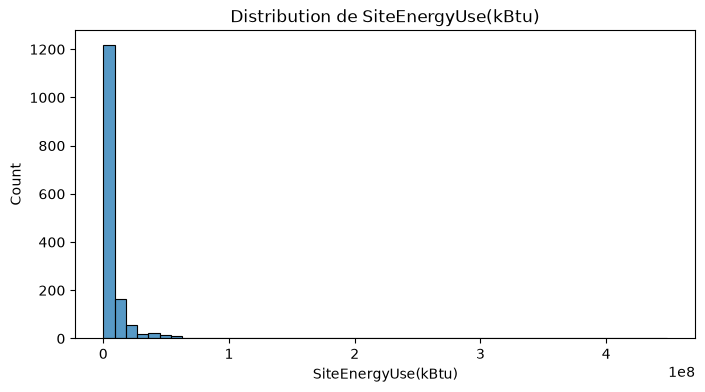

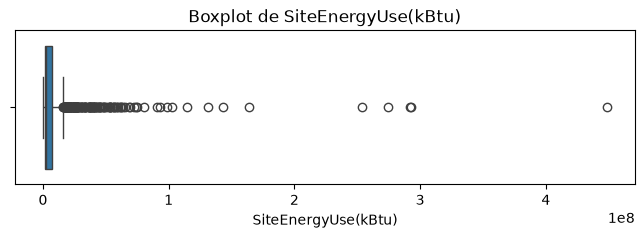

Skewness : 10.749389782229546


In [14]:
# Target pour le reste du projet = SiteEnergyUse
target = "SiteEnergyUse(kBtu)"

# Statistiques descriptives de la target : ça donne l'ordre de grandeur
# (min, max, moyenne, médiane, quartiles...)
print(building_consumption[target].describe())

# Histogramme : pour voir la forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(building_consumption[target], bins=50)
plt.title(f"Distribution de {target}")
plt.show()

# Boxplot : complémentaire de l'histogramme
plt.figure(figsize=(8, 2))
sns.boxplot(x=building_consumption[target])
plt.title(f"Boxplot de {target}")
plt.show()

# Skewness
print(f"Skewness : {building_consumption[target].skew()}")

In [15]:
# Ces visualisations ne sont pas très parlantes

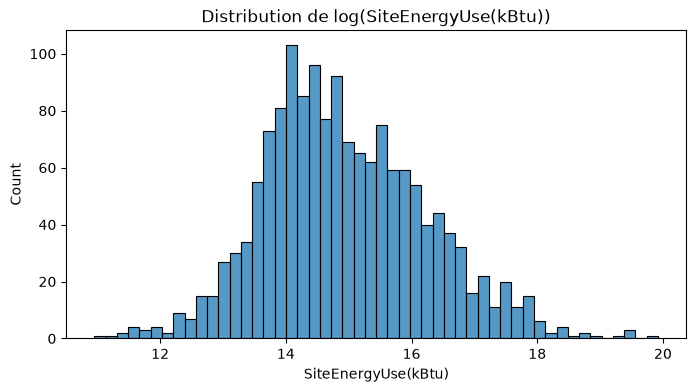

Skewness (log) : 0.35943406598607797


In [16]:
import numpy as np

# On visualise la distribution sur une échelle log pour "rapprocher" les petites
# et les grandes valeurs et ainsi mieux voir la vraie forme de la distribution
plt.figure(figsize=(8, 4))
sns.histplot(np.log(building_consumption[target]), bins=50)
plt.title(f"Distribution de log({target})")
plt.show()

# On regarde aussi le skewness sur cette échelle log, pour comparer
print(f"Skewness (log) : {np.log(building_consumption[target]).skew()}")

In [17]:
# Beaucoup plus parlant

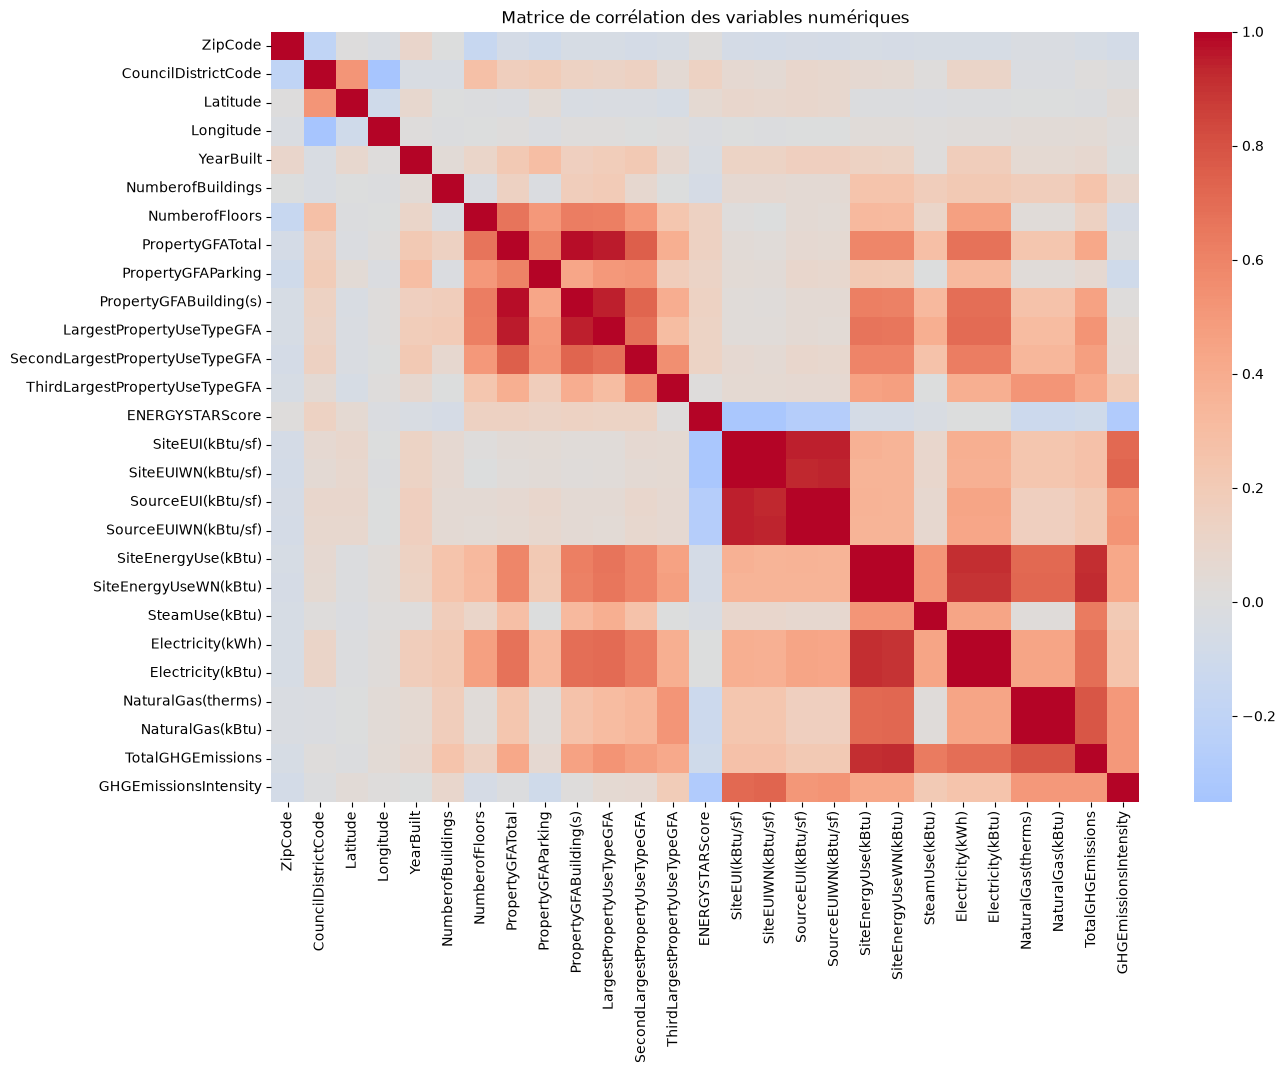

SiteEnergyUse(kBtu)                1.000000
SiteEnergyUseWN(kBtu)              0.996782
TotalGHGEmissions                  0.916958
Electricity(kWh)                   0.914189
Electricity(kBtu)                  0.914189
NaturalGas(therms)                 0.712444
NaturalGas(kBtu)                   0.712444
LargestPropertyUseTypeGFA          0.662611
PropertyGFABuilding(s)             0.615778
SecondLargestPropertyUseTypeGFA    0.598951
PropertyGFATotal                   0.590361
SteamUse(kBtu)                     0.519952
ThirdLargestPropertyUseTypeGFA     0.461474
GHGEmissionsIntensity              0.422187
SiteEUI(kBtu/sf)                   0.368740
SourceEUI(kBtu/sf)                 0.362712
SiteEUIWN(kBtu/sf)                 0.357974
SourceEUIWN(kBtu/sf)               0.354577
NumberofFloors                     0.325218
NumberofBuildings                  0.252975
PropertyGFAParking                 0.209962
YearBuilt                          0.136594
CouncilDistrictCode             

In [18]:
# On sélectionne uniquement les colonnes numériques pour la matrice de corrélation
# (les colonnes texte comme BuildingType ne peuvent pas être corrélées mathématiquement)
colonnes_numeriques = building_consumption.select_dtypes(include="number")

# Calcul de la matrice de corrélation (Pearson par défaut : mesure les relations LINEAIRES)
corr_matrix = colonnes_numeriques.corr()

# Heatmap : plus une case est claire/foncée (selon la palette), plus la corrélation est forte
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

# Pour aller plus vite que de scanner toute la heatmap à l'oeil :
# on isole uniquement la colonne de corrélation avec notre target, triée par ordre décroissant
correlations_target = corr_matrix[target].sort_values(ascending=False)
print(correlations_target)

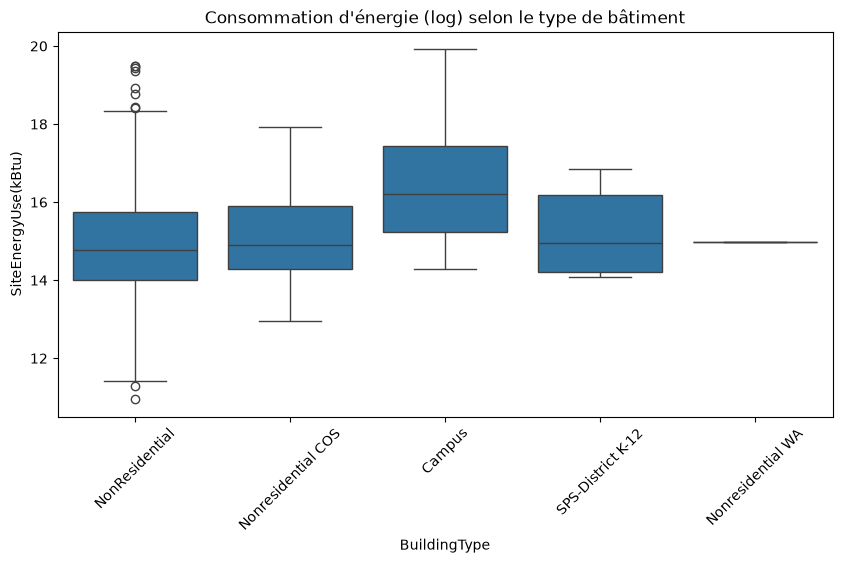

In [19]:
# Comparaison de la target selon le type de bâtiment (variable catégorielle)
# On utilise un boxplot plutôt qu'une corrélation, car BuildingType n'est pas numérique
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=building_consumption,
    x="BuildingType",
    y=np.log(building_consumption[target]),  # on garde le log, plus lisible
)
plt.xticks(rotation=45)
plt.title("Consommation d'énergie (log) selon le type de bâtiment")
plt.show()

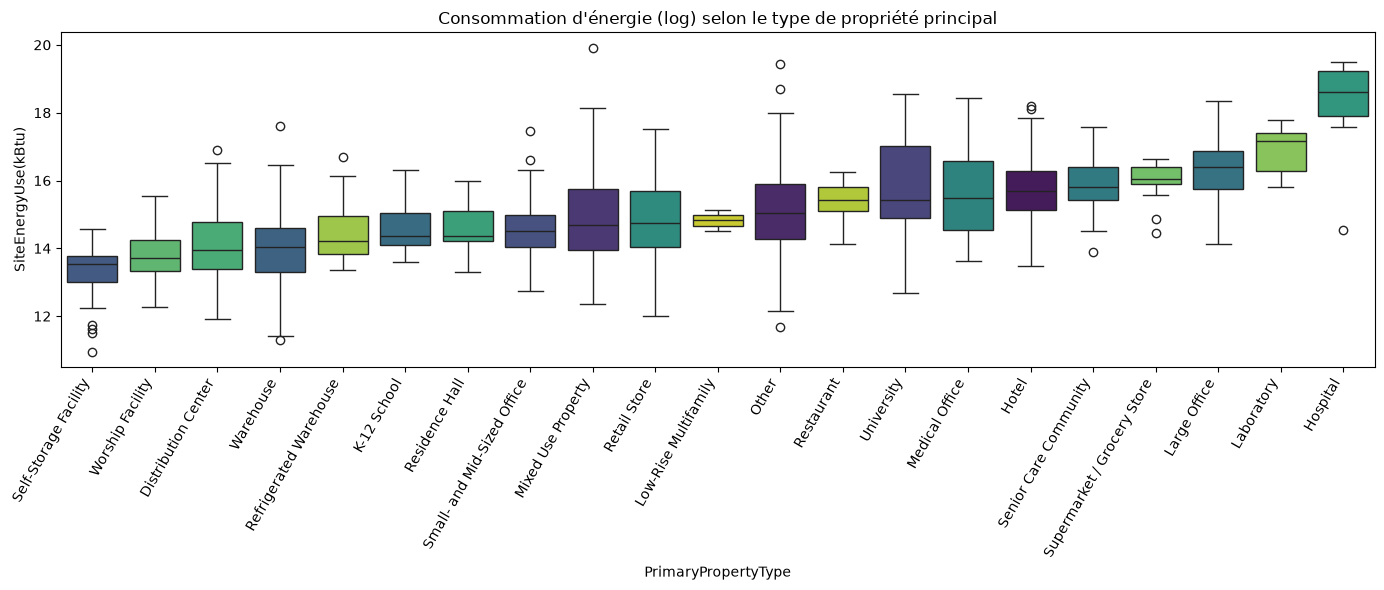

PrimaryPropertyType
Small- and Mid-Sized Office    284
Other                          241
Warehouse                      184
Large Office                   169
Mixed Use Property             112
Retail Store                    85
Hotel                           73
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  36
Self-Storage Facility           27
University                      23
Senior Care Community           20
Residence Hall                  17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             2
Name: count, dtype: int64


In [20]:
# PrimaryPropertyType est bien plus granulaire que BuildingType, donc plus informatif
# On trie les catégories par médiane de consommation pour rendre le graphique lisible
ordre_categories = (
    building_consumption.groupby("PrimaryPropertyType")[target]
    .median()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=building_consumption,
    x="PrimaryPropertyType",
    y=np.log(building_consumption[target]),
    hue="PrimaryPropertyType",
    palette="viridis",
    order=ordre_categories,  # applique le tri qu'on vient de calculer
)
plt.xticks(rotation=60, ha="right")
plt.title("Consommation d'énergie (log) selon le type de propriété principal")
plt.tight_layout()
plt.show()

# A regarder en complément : le nombre de bâtiments par catégorie
# (une catégorie avec 2-3 bâtiments donne un boxplot peu fiable, à interpréter avec prudence)
print(building_consumption["PrimaryPropertyType"].value_counts())

# Modélisation

### Import des modules

In [21]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes.

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource -> J'ai préféré faire en vectorisé, je trouve ça plus lisible

In [22]:
# CODE FEATURE ENGINEERING

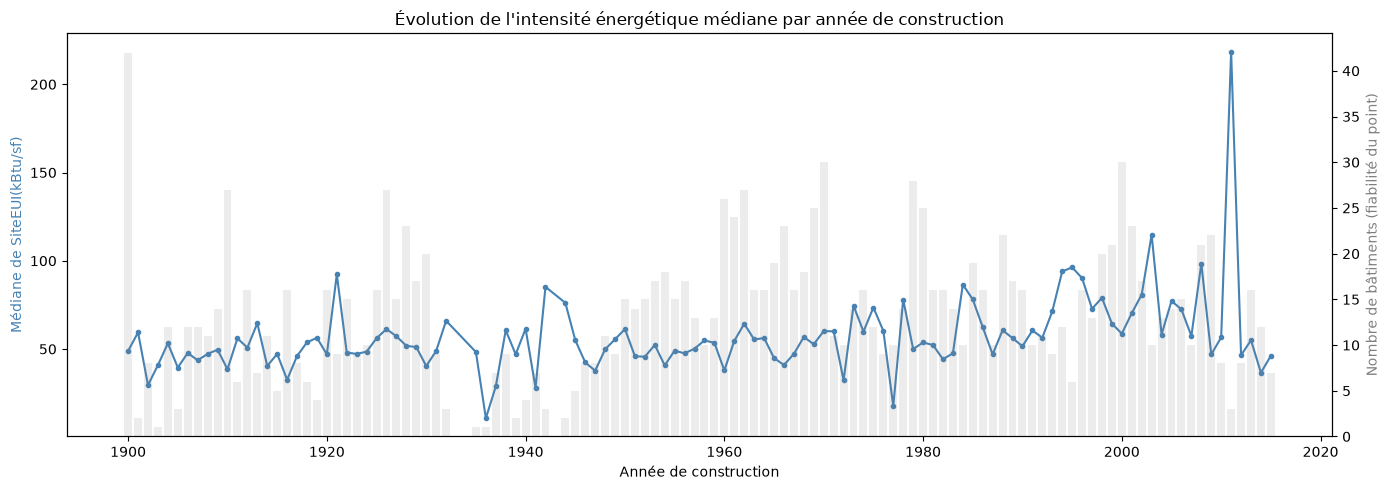

In [23]:
# Afin de pouvoir avancer dans le feature engineering sur le fait de faire du bucketing par tranche d'age de batiments
# Je vérifie si l'on peut observer une Année avec une cassure en terme d'efficience
# On utilise SiteEUI plutôt que la target brute, car on cherche ici un effet, indépendant de la taille du batiment
metrique_efficience = "SiteEUI(kBtu/sf)"

conso_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].median()
nb_batiments_par_annee = building_consumption.groupby("YearBuilt")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(conso_par_annee.index, conso_par_annee.values, color="steelblue", marker="o", markersize=3)
ax1.set_xlabel("Année de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par année de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_annee.index, nb_batiments_par_annee.values, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

In [24]:
# Pas vraiment d'année atypique, à part 2010 mais seulement 3 batiments contruits donc médiane biaisé
# Je test en dessous en ayant déjà regroupé par décénnies

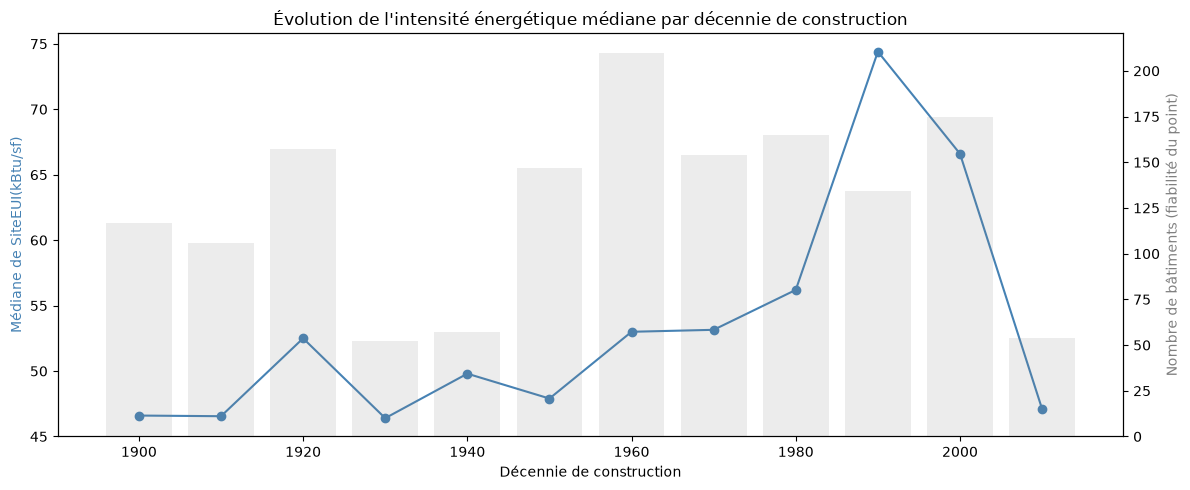

In [25]:
# Même analyse, mais regroupée par décennie plutôt que par année exacte
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

conso_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].median()
nb_batiments_par_decennie = building_consumption.groupby("decennie_construction")[metrique_efficience].count()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(conso_par_decennie.index, conso_par_decennie.values, color="steelblue", marker="o")
ax1.set_xlabel("Décennie de construction")
ax1.set_ylabel(f"Médiane de {metrique_efficience}", color="steelblue")
ax1.set_title("Évolution de l'intensité énergétique médiane par décennie de construction")

ax2 = ax1.twinx()
ax2.bar(nb_batiments_par_decennie.index, nb_batiments_par_decennie.values, width=8, alpha=0.15, color="gray")
ax2.set_ylabel("Nombre de bâtiments (fiabilité du point)", color="gray")

plt.tight_layout()
plt.show()

In [26]:
# On constate plusieurs tendances en fonction des décénnies, augmentation ou diminution de l'efficience par sqft

In [27]:
"""Feature Engineering - Temporalité"""

# On transforme l'année de construction en décennie (catégorielle)
building_consumption["decennie_construction"] = (building_consumption["YearBuilt"] // 10) * 10

# On vérifie que chaque décennie a un volume de bâtiments suffisant pour être exploitable
print(building_consumption["decennie_construction"].value_counts().sort_index())

decennie_construction
1900    117
1910    106
1920    157
1930     52
1940     57
1950    147
1960    210
1970    154
1980    165
1990    134
2000    175
2010     54
Name: count, dtype: int64


In [28]:
# Création de Variables pour connaître le type d'énérgie utilisée par le batiment
# Vérification des valeurs manquantes et de la distribution pour chaque source d'énergie
colonnes_energie = ["Electricity(kWh)", "NaturalGas(therms)", "SteamUse(kBtu)"]

for col in colonnes_energie:
    print(f"--- {col} ---")
    print(f"Nb de NaN : {building_consumption[col].isnull().sum()}")
    print(f"Nb de valeurs == 0 : {(building_consumption[col] == 0).sum()}")
    print(building_consumption[col].describe())
    print()

--- Electricity(kWh) ---
Nb de NaN : 0
Nb de valeurs == 0 : 2
count    1.528000e+03
mean     1.657026e+06
std      4.025887e+06
min     -3.382680e+04
25%      2.129975e+05
50%      4.966785e+05
75%      1.504899e+06
max      8.046087e+07
Name: Electricity(kWh), dtype: float64

--- NaturalGas(therms) ---
Nb de NaN : 0
Nb de valeurs == 0 : 438
count    1.528000e+03
mean     2.017102e+04
std      9.748393e+04
min      0.000000e+00
25%      0.000000e+00
50%      4.803805e+03
75%      1.524242e+04
max      2.979090e+06
Name: NaturalGas(therms), dtype: float64

--- SteamUse(kBtu) ---
Nb de NaN : 0
Nb de valeurs == 0 : 1418
count    1.528000e+03
mean     4.889622e+05
std      5.320966e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.349435e+08
Name: SteamUse(kBtu), dtype: float64



In [29]:
"""Feature Engineering - Type d'energie utilisée par le batiment"""

# Indicateurs binaires de présence de chaque source d'énergie
# On utilise "!= 0" plutôt que "> 0" pour bien capturer les cas de bâtiments
# producteurs (ex: Bullitt Center, qui a un solde électrique négatif)
building_consumption["Electricity_Use"] = (building_consumption["Electricity(kWh)"] != 0).astype(int)
building_consumption["Gas_Use"] = (building_consumption["NaturalGas(therms)"] != 0).astype(int)
building_consumption["Steam_Use"] = (building_consumption["SteamUse(kBtu)"] != 0).astype(int)

# Combien de bâtiments utilisent chaque source
print(building_consumption[["Electricity_Use", "Gas_Use", "Steam_Use"]].sum())

Electricity_Use    1526
Gas_Use            1090
Steam_Use           110
dtype: int64


In [30]:
"""Feature Engineering - Usages multiples"""

# Indicateurs binaires : le bâtiment a-t-il un usage secondaire / tertiaire ?
building_consumption["Has_Second_Use"] = (building_consumption["SecondLargestPropertyUseType"] != "None").astype(int)
building_consumption["Has_Third_Use"] = (building_consumption["ThirdLargestPropertyUseType"] != "None").astype(int)

# Proportions : quelle part de la surface totale est occupée par ces usages secondaire/tertiaire ?
# (entre 0 et 1 : 0 = aucune surface dédiée à cet usage, 1 = 100% du bâtiment)
building_consumption["Prop_Second_Use"] = building_consumption["SecondLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]
building_consumption["Prop_Third_Use"] = building_consumption["ThirdLargestPropertyUseTypeGFA"] / building_consumption["PropertyGFATotal"]

# Contrôle rapide : cohérence des nouvelles colonnes
print(building_consumption[["Has_Second_Use", "Has_Third_Use", "Prop_Second_Use", "Prop_Third_Use"]].describe())

       Has_Second_Use  Has_Third_Use  Prop_Second_Use  Prop_Third_Use
count     1528.000000    1528.000000      1528.000000     1528.000000
mean         0.545812       0.225785         0.129743        0.023275
std          0.498060       0.418235         0.170282        0.064017
min          0.000000       0.000000         0.000000        0.000000
25%          0.000000       0.000000         0.000000        0.000000
50%          1.000000       0.000000         0.000000        0.000000
75%          1.000000       0.000000         0.250000        0.000000
max          1.000000       1.000000         1.293221        0.929094


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [31]:
# CODE PREPARATION DES FEATURES

In [32]:
"""Suppression de Features redondantes"""

# --- Groupe 1 : Data leakage ---
colonnes_leakage = [
    "SiteEnergyUseWN(kBtu)",
    "Electricity(kWh)", "Electricity(kBtu)",
    "NaturalGas(therms)", "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "TotalGHGEmissions", "GHGEmissionsIntensity",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "ENERGYSTARScore",
]

# --- Groupe 2 : Colonnes devenues constantes après nos filtres ---
colonnes_constantes = ["ComplianceStatus", "DefaultData"]

# --- Groupe 3 : Identifiant peu exploitable ---
colonnes_identifiants = ["PropertyName"]

# --- Groupe 4 : Colonnes brutes redondantes avec des features déjà créées ---
# YearBuilt -> remplacée par decennie_construction (qui capture mieux la relation non-monotone)
# Second/ThirdLargestPropertyUseTypeGFA -> remplacées par Prop_Second_Use / Prop_Third_Use
# (produit exact de la proportion x PropertyGFATotal, déjà présent par ailleurs)
colonnes_redondantes = [
    "YearBuilt",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
]

# --- Groupe 5 : Cardinalité trop élevée pour être exploitable (quasi 1 valeur par bâtiment) ---
# Son information utile a déjà été extraite via Has_Second_Use / Has_Third_Use / Prop_Second_Use / Prop_Third_Use
colonnes_trop_eparses = ["ListOfAllPropertyUseTypes"]

building_consumption = building_consumption.drop(
    columns=colonnes_leakage + colonnes_constantes + colonnes_identifiants + colonnes_redondantes + colonnes_trop_eparses
)

# Contrôle : combien de colonnes te reste-t-il, et sont-elles cohérentes ?
print(f"Nombre de colonnes restantes : {building_consumption.shape[1]}")
building_consumption.info()

Nombre de colonnes restantes : 25
<class 'pandas.DataFrame'>
Index: 1528 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1528 non-null   str    
 1   PrimaryPropertyType           1528 non-null   str    
 2   ZipCode                       1515 non-null   float64
 3   CouncilDistrictCode           1528 non-null   int64  
 4   Neighborhood                  1528 non-null   str    
 5   Latitude                      1528 non-null   float64
 6   Longitude                     1528 non-null   float64
 7   NumberofBuildings             1528 non-null   float64
 8   NumberofFloors                1528 non-null   int64  
 9   PropertyGFATotal              1528 non-null   int64  
 10  PropertyGFAParking            1528 non-null   int64  
 11  PropertyGFABuilding(s)        1528 non-null   int64  
 12  LargestPropertyUseType        1528 non-null 

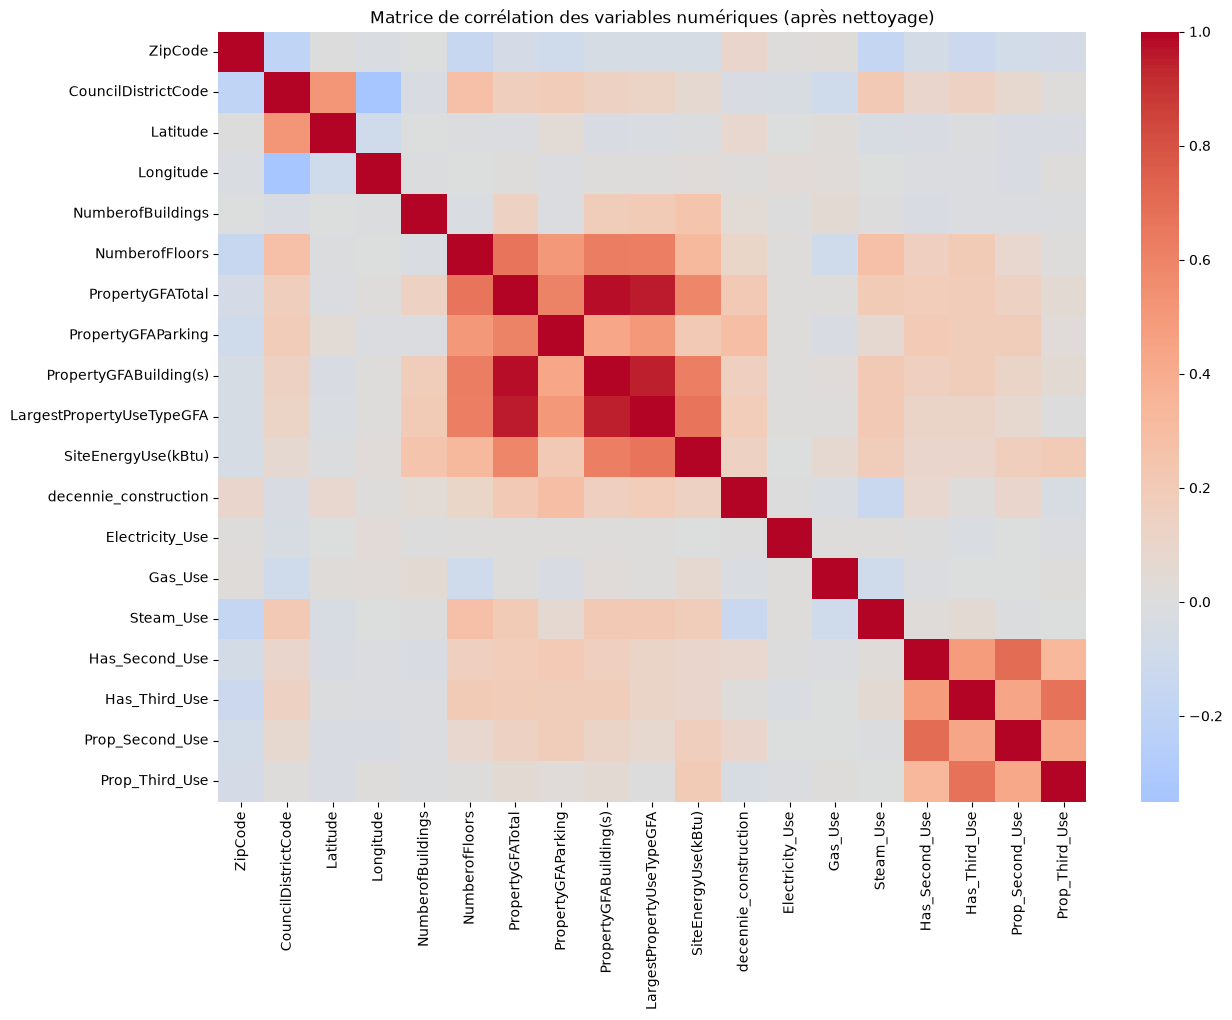

In [33]:
# On relance la matrice de corrélation sur le dataframe nettoyé
# (après suppression du leakage et des redondances "par formule")
colonnes_numeriques = building_consumption.select_dtypes(include="number")
corr_matrix = colonnes_numeriques.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des variables numériques (après nettoyage)")
plt.show()

In [34]:
"""Calcul de l'IQR pour identifier de potentiels Outliers au sens statistique"""
# Méthode IQR (interquartile range) : une valeur est considérée outlier statistique
# si elle est en dehors de [Q1 - 1.5*IQR ; Q3 + 1.5*IQR]
Q1 = building_consumption[target].quantile(0.25)
Q3 = building_consumption[target].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

nb_outliers = ((building_consumption[target] < borne_basse) | (building_consumption[target] > borne_haute)).sum()
print(f"Nombre d'outliers statistiques (méthode IQR) : {nb_outliers} sur {len(building_consumption)} bâtiments")

Nombre d'outliers statistiques (méthode IQR) : 169 sur 1528 bâtiments


In [35]:
# IQR sur l'échelle brute de la target
Q1 = building_consumption[target].quantile(0.25)
Q3 = building_consumption[target].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

nb_outliers_brut = ((building_consumption[target] < borne_basse) | (building_consumption[target] > borne_haute)).sum()
print(f"IQR (échelle brute) : bornes [{borne_basse:.0f} ; {borne_haute:.0f}]")
print(f"Outliers détectés : {nb_outliers_brut} / {len(building_consumption)} ({100*nb_outliers_brut/len(building_consumption):.1f}%)")

# Même calcul, mais sur l'échelle log (rappel : on avait vu que log(target) est bien plus symétrique, skewness ≈ 0.36)
log_target = np.log(building_consumption[target])
Q1_log = log_target.quantile(0.25)
Q3_log = log_target.quantile(0.75)
IQR_log = Q3_log - Q1_log
borne_basse_log = Q1_log - 1.5 * IQR_log
borne_haute_log = Q3_log + 1.5 * IQR_log

nb_outliers_log = ((log_target < borne_basse_log) | (log_target > borne_haute_log)).sum()
print(f"IQR (échelle log) : bornes [{np.exp(borne_basse_log):.0f} ; {np.exp(borne_haute_log):.0f}] (reconverties en kBtu)")
print(f"Outliers détectés : {nb_outliers_log} / {len(building_consumption)} ({100*nb_outliers_log/len(building_consumption):.1f}%)")

IQR (échelle brute) : bornes [-7755116 ; 16242034]
Outliers détectés : 169 / 1528 (11.1%)
IQR (échelle log) : bornes [88512 ; 101783533] (reconverties en kBtu)
Outliers détectés : 12 / 1528 (0.8%)


In [36]:
# On retient la version log (la moins invasive, cohérente avec la vraie forme de la distribution)
# On applique la suppression sur les bornes calculées précédemment (borne_basse_log / borne_haute_log)
nb_avant = building_consumption.shape[0]

building_consumption = building_consumption[
    (log_target >= borne_basse_log) & (log_target <= borne_haute_log)
]

nb_apres = building_consumption.shape[0]
print(f"Nombre de bâtiments après suppression des outliers (IQR sur échelle log) : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Nombre de bâtiments après suppression des outliers (IQR sur échelle log) : 1516
Lignes supprimées : 12


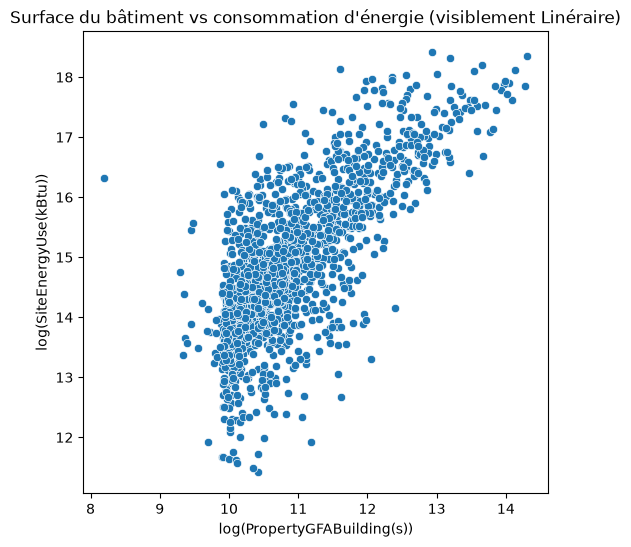

In [37]:
# Relation entre la surface du bâtiment et la consommation d'énergie
# On passe les deux axes en log, cohérent avec ce qu'on a observé sur la distribution de la target
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=np.log(building_consumption["PropertyGFABuilding(s)"]),
    y=np.log(building_consumption[target]),
)
plt.xlabel("log(PropertyGFABuilding(s))")
plt.ylabel(f"log({target})")
plt.title("Surface du bâtiment vs consommation d'énergie (visiblement Linéraire)")
plt.show()

In [38]:
"""Nettoyage de colonnes catégorielles"""

#
# On force decennie_construction en texte pour qu'elle soit bien traitée comme catégorielle (OneHot), pas comme une quantité (scaling)
building_consumption["decennie_construction"] = building_consumption["decennie_construction"].astype(str)

# Même logique que pour decennie_construction : ce sont des identifiants de zones, pas des quantités
building_consumption["CouncilDistrictCode"] = building_consumption["CouncilDistrictCode"].astype(str)
building_consumption["ZipCode"] = building_consumption["ZipCode"].astype(str)

In [39]:
"""Méthode pour déterminer un nombre de catégories suffisant pour couvrir 90% des bâtiments"""
# Méthode : on choisit le nombre minimal de catégories qui couvre au moins X% des bâtiments,
# plutôt que de fixer max_categories arbitrairement
seuil_couverture = 0.90  # on veut qu'au moins 90% des bâtiments soient dans une vraie catégorie, pas "infrequent"

vc = building_consumption["ZipCode"].value_counts()
couverture_cumulee = vc.cumsum() / vc.sum()

# Nombre de catégories nécessaires pour atteindre le seuil
nb_categories_necessaire = (couverture_cumulee < seuil_couverture).sum() + 1
print(f"Nombre de catégories nécessaire pour couvrir {seuil_couverture*100:.0f}% des bâtiments : {nb_categories_necessaire}")
print(f"Couverture réelle avec ce nombre : {couverture_cumulee.iloc[nb_categories_necessaire-1]*100:.1f}%")

Nombre de catégories nécessaire pour couvrir 90% des bâtiments : 18
Couverture réelle avec ce nombre : 91.3%


In [40]:
from sklearn.preprocessing import OneHotEncoder

# On sépare d'abord les features catégorielles à traiter
colonnes_categorielles = building_consumption.select_dtypes(include="object").columns.tolist()
print("Colonnes catégorielles à encoder :", colonnes_categorielles)

# max_categories=18 : au-delà de 18 valeurs les plus fréquentes, le reste est regroupé dans une catégorie "infrequent"
# -> évite l'explosion du nombre de colonnes sur LargestPropertyUseType, SecondLargestPropertyUseType, ThirdLargestPropertyUseType
encoder = OneHotEncoder(handle_unknown="ignore", max_categories=18, sparse_output=False)

# Test rapide sur une seule colonne pour vérifier le comportement avant de l'intégrer au ColumnTransformer
test_encodage = encoder.fit_transform(building_consumption[["LargestPropertyUseType"]])
print(f"Nombre de colonnes générées pour LargestPropertyUseType : {test_encodage.shape[1]}")

Colonnes catégorielles à encoder : ['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'decennie_construction']
Nombre de colonnes générées pour LargestPropertyUseType : 18


C:\Users\Mu\AppData\Local\Temp\ipykernel_36176\1400315537.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_categorielles = building_consumption.select_dtypes(include="object").columns.tolist()


In [41]:
# On sépare les features (X) de la target (y)
X = building_consumption.drop(columns=[target])
y = building_consumption[target]

print(f"Shape de X : {X.shape}")
print(f"Shape de y : {y.shape}")

Shape de X : (1516, 24)
Shape de y : (1516,)


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# On identifie les 2 groupes de colonnes à partir de X (pas building_consumption, pour être sûr de ne pas inclure la target)
colonnes_categorielles = X.select_dtypes(include="object").columns.tolist()
colonnes_numeriques = X.select_dtypes(include="number").columns.tolist()

print("Catégorielles :", colonnes_categorielles)
print("Numériques :", colonnes_numeriques)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=18, sparse_output=False), colonnes_categorielles),
    ("num", StandardScaler(), colonnes_numeriques),
])

# On applique la transformation
X_prepared = preprocessor.fit_transform(X)
print(f"Shape de X après transformation : {X_prepared.shape}")

Catégorielles : ['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'decennie_construction']
Numériques : ['Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'Electricity_Use', 'Gas_Use', 'Steam_Use', 'Has_Second_Use', 'Has_Third_Use', 'Prop_Second_Use', 'Prop_Third_Use']
Shape de X après transformation : (1516, 143)


C:\Users\Mu\AppData\Local\Temp\ipykernel_36176\4215558756.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_categorielles = X.select_dtypes(include="object").columns.tolist()


### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [43]:
# CODE COMPARAISON DES MODELES

In [44]:
'''Creation d'un jeu train test'''
from sklearn.model_selection import train_test_split

# random_state fixé pour la reproductibilité (recommandation de l'étape 4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]} bâtiments")
print(f"Taille test  : {X_test.shape[0]} bâtiments")

Taille train : 1212 bâtiments
Taille test  : 304 bâtiments


In [45]:
# fit_transform sur le train : le preprocessor "apprend" les moyennes/écart-types (StandardScaler)
# et les catégories rencontrées (OneHotEncoder) uniquement depuis le train
X_train_prepared = preprocessor.fit_transform(X_train)

# transform seul sur le test : on applique ce qui a été appris sur le train, sans rien recalculer
X_test_prepared = preprocessor.transform(X_test)

print(f"Shape X_train_prepared : {X_train_prepared.shape}")
print(f"Shape X_test_prepared  : {X_test_prepared.shape}")

Shape X_train_prepared : (1212, 143)
Shape X_test_prepared  : (304, 143)


In [46]:
"""Calcul d'une base"""
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyRegressor
import pandas as pd

# Baseline : un "modèle" qui prédit toujours la même valeur (par défaut, la moyenne de y_train)
# Sert de seuil minimal : si un vrai modèle fait moins bien que ça, il y a un problème
dummy = DummyRegressor(strategy="mean")

# cross_validate découpe X_train en plusieurs "plis" (folds), entraîne et évalue sur chacun
# scoring : plusieurs métriques en une fois ; return_train_score=True pour comparer train vs validation (utile pour repérer l'overfitting plus tard)
scores_dummy = cross_validate(
    dummy, X_train_prepared, y_train,
    cv=5,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    return_train_score=True,
)

resultats_dummy = pd.DataFrame(scores_dummy)
print(resultats_dummy)
print()
print("Moyennes sur les 5 folds :")
print(resultats_dummy.mean())

   fit_time  score_time   test_r2  train_r2  test_neg_mean_absolute_error  \
0  0.000654    0.001036 -0.006139       0.0                 -6.208967e+06   
1  0.000527    0.000862 -0.005774       0.0                 -6.452730e+06   
2  0.000495    0.000763 -0.002629       0.0                 -6.763526e+06   
3  0.000488    0.000752 -0.015510       0.0                 -7.638059e+06   
4  0.000486    0.000754 -0.004496       0.0                 -6.360466e+06   

   train_neg_mean_absolute_error  test_neg_root_mean_squared_error  \
0                  -6.882101e+06                     -9.797031e+06   
1                  -6.833170e+06                     -1.136626e+07   
2                  -6.576242e+06                     -1.143130e+07   
3                  -6.223876e+06                     -1.393281e+07   
4                  -6.831931e+06                     -1.010081e+07   

   train_neg_root_mean_squared_error  
0                      -1.177138e+07  
1                      -1.141249e+07  

In [47]:
def evaluer_modele(nom, modele, X, y, cv=5):
    """Entraîne et évalue un modèle par validation croisée, retourne un résumé des métriques moyennes."""
    scores = cross_validate(
        modele, X, y,
        cv=cv,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_train_score=True,
    )
    resume = pd.DataFrame(scores).mean()
    resume["modele"] = nom
    return resume

# On relance le dummy avec la fonction, pour vérifier qu'elle retrouve bien les mêmes chiffres qu'avant
resultat_dummy = evaluer_modele("Dummy (baseline)", DummyRegressor(strategy="mean"), X_train_prepared, y_train)
print(resultat_dummy)

fit_time                                     0.000504
score_time                                   0.000812
test_r2                                      -0.00691
train_r2                                          0.0
test_neg_mean_absolute_error          -6684749.814361
train_neg_mean_absolute_error         -6669463.911944
test_neg_root_mean_squared_error      -11325644.54962
train_neg_root_mean_squared_error    -11393707.178423
modele                               Dummy (baseline)
dtype: object


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

resultat_linear = evaluer_modele("Linear Regression", LinearRegression(), X_train_prepared, y_train)
resultat_svr = evaluer_modele("SVR", SVR(), X_train_prepared, y_train)
resultat_rf = evaluer_modele("Random Forest", RandomForestRegressor(random_state=42), X_train_prepared, y_train)

# On rassemble tous les résultats dans un seul tableau comparatif
comparaison = pd.DataFrame([resultat_dummy, resultat_linear, resultat_svr, resultat_rf])
comparaison = comparaison.set_index("modele")
print(comparaison)

                   fit_time  score_time   test_r2  train_r2  \
modele                                                        
Dummy (baseline)   0.000504    0.000812 -0.006910  0.000000   
Linear Regression  0.008235    0.001024  0.584359  0.731534   
SVR                0.036854    0.019267 -0.131501 -0.128959   
Random Forest      0.722953    0.007444  0.653942  0.954216   

                   test_neg_mean_absolute_error  \
modele                                            
Dummy (baseline)                  -6.684750e+06   
Linear Regression                 -4.048340e+06   
SVR                               -5.462585e+06   
Random Forest                     -3.123748e+06   

                   train_neg_mean_absolute_error  \
modele                                             
Dummy (baseline)                   -6.669464e+06   
Linear Regression                  -3.382528e+06   
SVR                                -5.460003e+06   
Random Forest                      -1.143205e+06   

 

In [49]:
# On repart sur la target en log, cohérent avec ce qu'on a appris sur sa distribution
y_train_log = np.log(y_train)

resultat_dummy = evaluer_modele("Dummy (baseline)", DummyRegressor(strategy="mean"), X_train_prepared, y_train_log)
resultat_linear = evaluer_modele("Linear Regression", LinearRegression(), X_train_prepared, y_train_log)
resultat_svr = evaluer_modele("SVR", SVR(), X_train_prepared, y_train_log)
resultat_rf = evaluer_modele("Random Forest", RandomForestRegressor(random_state=42), X_train_prepared, y_train_log)

comparaison_log = pd.DataFrame([resultat_dummy, resultat_linear, resultat_svr, resultat_rf])
comparaison_log = comparaison_log.set_index("modele")
print(comparaison_log)

                   fit_time  score_time   test_r2  train_r2  \
modele                                                        
Dummy (baseline)   0.000591    0.000944 -0.007070  0.000000   
Linear Regression  0.008276    0.000998  0.569660  0.678466   
SVR                0.036745    0.015967  0.677138  0.817549   
Random Forest      0.624008    0.007412  0.692447  0.956748   

                   test_neg_mean_absolute_error  \
modele                                            
Dummy (baseline)                      -1.010090   
Linear Regression                     -0.634615   
SVR                                   -0.539612   
Random Forest                         -0.517624   

                   train_neg_mean_absolute_error  \
modele                                             
Dummy (baseline)                       -1.009298   
Linear Regression                      -0.551508   
SVR                                    -0.361161   
Random Forest                          -0.192384   

 

Je vois sur les resultats ci-dessus que le Random Forest, malgré un overfit plus prononcé, obtient tout de même des résultats probant.

Je pars sur RandomForest et on va tenter de corriger l'overfit avec un gridsearch.
Il sera plus facile de voir si l'on doit se rabattre sur le SVR ensuite en fonction du résultat obtenu post-correction.

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [50]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

In [51]:
from sklearn.model_selection import GridSearchCV

# Petite grille de test (10 combinaisons) pour vérifier que tout fonctionne avant de passer à grande échelle
petite_grille = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],  # None = pas de limite (comportement par défaut, celui qui overfit)
    "min_samples_leaf": [1, 5],
}
# 2 x 3 x 2 = 12 combinaisons, proche des 10 recommandées

grid_search_test = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=petite_grille,
    cv=5,
    scoring="r2",
    n_jobs=-1,  # utilise tous les cœurs du processeur pour paralléliser, accélère le calcul
)

grid_search_test.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres : {grid_search_test.best_params_}")
print(f"Meilleur score (r2, validation croisée) : {grid_search_test.best_score_:.3f}")

Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Meilleur score (r2, validation croisée) : 0.692


In [52]:
# Grille élargie, en poussant plus loin dans les deux directions identifiées
grille_elargie = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
}
# 3 x 5 x 4 = 60 combinaisons x 5 folds = 300 entraînements -> attends-toi à plusieurs minutes

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=grille_elargie,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_search_rf.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur score (r2, validation croisée) : {grid_search_rf.best_score_:.3f}")

Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Meilleur score (r2, validation croisée) : 0.695


In [53]:
petite_grille_svr = {
    "C": [1, 10, 50],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf", "linear"],
}
# 3 x 3 x 2 = 18 combinaisons

grid_search_svr = GridSearchCV(
    SVR(),
    param_grid=petite_grille_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid_search_svr.fit(X_train_prepared, y_train_log)

print(f"Meilleurs paramètres SVR : {grid_search_svr.best_params_}")
print(f"Meilleur score SVR (r2, validation croisée) : {grid_search_svr.best_score_:.3f}")

Meilleurs paramètres SVR : {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Meilleur score SVR (r2, validation croisée) : 0.682


In [54]:
from sklearn.metrics import r2_score

# On récupère le meilleur modèle trouvé automatiquement (déjà réentraîné sur tout X_train par GridSearchCV)
meilleur_rf = grid_search_rf.best_estimator_

r2_train = r2_score(y_train_log, meilleur_rf.predict(X_train_prepared))
r2_test = r2_score(np.log(y_test), meilleur_rf.predict(X_test_prepared))

print(f"R2 train : {r2_train:.3f}")
print(f"R2 test  : {r2_test:.3f}")
print(f"Ecart (overfitting) : {r2_train - r2_test:.3f}")

R2 train : 0.956
R2 test  : 0.729
Ecart (overfitting) : 0.227


In [55]:
# Récupération des noms de colonnes après transformation (le ColumnTransformer les garde en mémoire)
noms_colonnes = preprocessor.get_feature_names_out()
print(f"Nombre de noms récupérés : {len(noms_colonnes)}")  # doit correspondre à X_train_prepared.shape[1]

# Association nom de feature <-> importance, dans un DataFrame pour trier/visualiser facilement
importances = pd.DataFrame({
    "feature": noms_colonnes,
    "importance": meilleur_rf.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances.head(15))

Nombre de noms récupérés : 143
                                               feature  importance
132                              num__PropertyGFATotal    0.571506
135                     num__LargestPropertyUseTypeGFA    0.047996
134                        num__PropertyGFABuilding(s)    0.046924
128                                      num__Latitude    0.026707
129                                     num__Longitude    0.023038
20                  cat__PrimaryPropertyType_Warehouse    0.022752
67   cat__LargestPropertyUseType_Non-Refrigerated W...    0.022587
18   cat__PrimaryPropertyType_Supermarket / Grocery...    0.021795
137                                       num__Gas_Use    0.020586
141                               num__Prop_Second_Use    0.012373
77   cat__LargestPropertyUseType_Supermarket/Grocer...    0.011392
131                                num__NumberofFloors    0.010935
79      cat__LargestPropertyUseType_infrequent_sklearn    0.009892
15      cat__PrimaryPropertyTyp

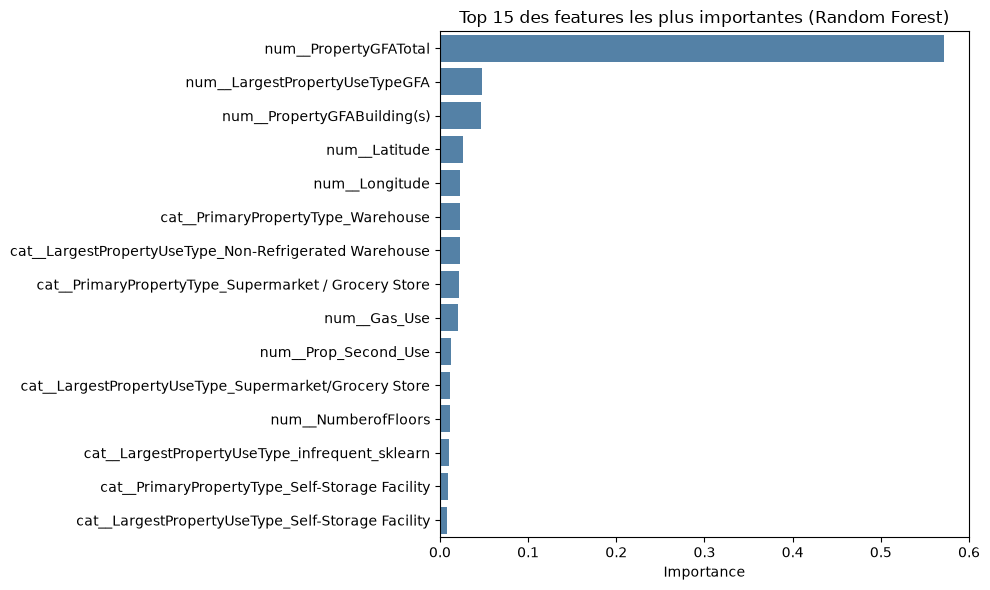

In [56]:
top_n = 15

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(top_n), x="importance", y="feature", color="steelblue")
plt.title(f"Top {top_n} des features les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [57]:
"""On repasse en unité réelles hors du log"""
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prédictions du modèle optimisé (encore en log)
y_pred_log = meilleur_rf.predict(X_test_prepared)

# Reconversion en vraies unités (kBtu)
y_pred_reel = np.exp(y_pred_log)

# Métriques finales, directement comparables aux vraies valeurs de consommation
mae_reel = mean_absolute_error(y_test, y_pred_reel)
rmse_reel = mean_squared_error(y_test, y_pred_reel) ** 0.5
r2_reel = r2_score(y_test, y_pred_reel)

print(f"MAE (kBtu) : {mae_reel:,.0f}")
print(f"RMSE (kBtu) : {rmse_reel:,.0f}")
print(f"R2 (échelle réelle) : {r2_reel:.3f}")

MAE (kBtu) : 2,832,866
RMSE (kBtu) : 6,431,402
R2 (échelle réelle) : 0.644


In [58]:
# Erreur relative par bâtiment, en % : chaque bâtiment compte "à égalité", contrairement au MAE
erreur_relative = (y_test - y_pred_reel).abs() / y_test * 100
print(f"Erreur relative médiane : {erreur_relative.median():.1f}%")
print(f"Erreur relative moyenne : {erreur_relative.mean():.1f}%")

# Part des bâtiments par tranche d'erreur (sert au graphique de la slide 12)
tranches = pd.cut(erreur_relative, [0, 10, 25, 50, 100, float("inf")], right=False)
print(tranches.value_counts(sort=False, normalize=True).round(3))

Erreur relative médiane : 37.4%
Erreur relative moyenne : 59.5%
SiteEnergyUse(kBtu)
[0.0, 10.0)      0.141
[10.0, 25.0)     0.247
[25.0, 50.0)     0.270
[50.0, 100.0)    0.217
[100.0, inf)     0.125
Name: proportion, dtype: float64
